# 04 – Modell-Subset Analyse

Alle Modelle trainieren auf den **Top-406 Spots** aus `data_final.parquet`,
ausgewählt nach höchster Datenvollständigkeit (`clean = 1 − NaN/total`).

Dieses Notebook analysiert: Ist das ein repräsentatives und qualitativ gutes Subset?

**Fragen:**
- Wie viele Zeilen / Zeiträume pro Spot?
- Wie vollständig sind die Zeitreihen?
- Geografische Verteilung (Lat/Lon)?
- Anlagengrößen (kwp_est) — repräsentativ?
- Saisonale Abdeckung?
- Vergleich Subset vs. Gesamtdatensatz

In [1]:
import gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pyarrow.dataset as ds
import pyarrow.compute as pc
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('data/processed/data_final.parquet')
TARGET    = 'kwh_norm'
N_SUBSET  = 406   # gleich wie in allen train_kaggle_*.py Scripts

## 1. Subset-Selektion (exakt wie in den Training-Scripts)

In [2]:
# ── Schritt 1: gleiche Selektion wie train_kaggle_*.py ───────────────────────
print('Lade Spot-Statistiken (nur spot_uuid + kwh_norm)...')
meta = ds.dataset(str(DATA_PATH)).to_table(columns=['spot_uuid', TARGET]).to_pandas()

stats_all = meta.groupby('spot_uuid', observed=True)[TARGET].agg(
    total  = 'count',
    nans   = lambda x: x.isna().sum(),
    mean   = 'mean',
    std    = 'std',
).reset_index()
stats_all['clean'] = 1 - (stats_all['nans'] / stats_all['total'])

# Top-406 Spots
stats_sub = stats_all.sort_values(['clean', 'total'], ascending=False).iloc[:N_SUBSET].copy()
selected  = stats_sub['spot_uuid'].tolist()

del meta; gc.collect()

n_total = len(stats_all)
print(f'Gesamtdatensatz: {n_total:,} Spots')
print(f'Subset:          {N_SUBSET:,} Spots ({N_SUBSET/n_total*100:.1f}% aller Spots)')
print(f'Vollständigkeit Subset:      min={stats_sub["clean"].min():.3f}  median={stats_sub["clean"].median():.3f}  mean={stats_sub["clean"].mean():.3f}')
print(f'Vollständigkeit Gesamt:      min={stats_all["clean"].min():.3f}  median={stats_all["clean"].median():.3f}  mean={stats_all["clean"].mean():.3f}')

Lade Spot-Statistiken (nur spot_uuid + kwh_norm)...
Gesamtdatensatz: 3,016 Spots
Subset:          406 Spots (13.5% aller Spots)
Vollständigkeit Subset:      min=0.985  median=0.990  mean=0.990
Vollständigkeit Gesamt:      min=0.570  median=0.954  mean=0.939


## 2. Vollständigkeit & Zeitreihenlänge

Vergleich der Datenvollständigkeit (`clean rate`) und Zeitreihenlänge zwischen dem Subset und dem Gesamtdatensatz.

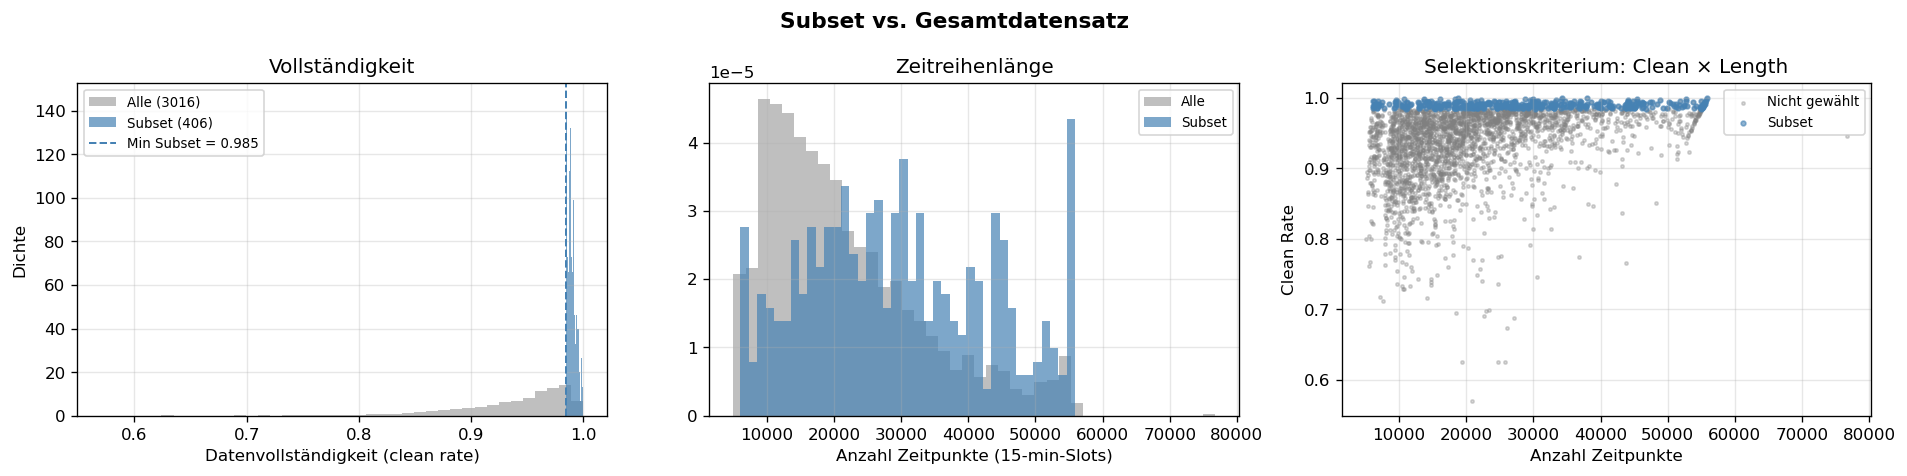

,Spots,Ø Zeitpunkte,Median Zeitpunkte,Ø Clean Rate,Min Clean Rate
Gruppe,,,,,
Gesamt,3016,"21,426","18,450",0.939,0.570
Subset,406,"29,500","28,500",0.990,0.985


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Subset vs. Gesamtdatensatz', fontsize=13, fontweight='bold')

# Vollständigkeit
ax = axes[0]
ax.hist(stats_all['clean'], bins=40, alpha=0.5, color='grey',  label=f'Alle ({n_total})', density=True)
ax.hist(stats_sub['clean'], bins=40, alpha=0.7, color='steelblue', label=f'Subset ({N_SUBSET})', density=True)
ax.axvline(stats_sub['clean'].min(), color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Min Subset = {stats_sub["clean"].min():.3f}')
ax.set_xlabel('Datenvollständigkeit (clean rate)')
ax.set_ylabel('Dichte')
ax.set_title('Vollständigkeit')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Anzahl Zeitpunkte pro Spot
ax = axes[1]
ax.hist(stats_all['total'], bins=40, alpha=0.5, color='grey',  label='Alle', density=True)
ax.hist(stats_sub['total'], bins=40, alpha=0.7, color='steelblue', label='Subset', density=True)
ax.set_xlabel('Anzahl Zeitpunkte (15-min-Slots)')
ax.set_title('Zeitreihenlänge')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Clean rate als Scatter: Total vs Clean
ax = axes[2]
ax.scatter(stats_all['total'], stats_all['clean'], s=4, alpha=0.3, color='grey', label='Nicht gewählt')
ax.scatter(stats_sub['total'], stats_sub['clean'], s=8, alpha=0.6, color='steelblue', label='Subset')
ax.set_xlabel('Anzahl Zeitpunkte')
ax.set_ylabel('Clean Rate')
ax.set_title('Selektionskriterium: Clean × Length')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabellarische Zusammenfassung
summary = pd.DataFrame({
    'Gesamt': stats_all[['total', 'clean']].describe().loc[['mean','50%','min','max']].T.iloc[:,0],
    'Subset': stats_sub[['total', 'clean']].describe().loc[['mean','50%','min','max']].T.iloc[:,0],
}).T
# Rebuild nicely
rows = []
for name, df_ in [('Gesamt', stats_all), ('Subset', stats_sub)]:
    rows.append({
        'Gruppe': name,
        'Spots': len(df_),
        'Ø Zeitpunkte': f"{df_['total'].mean():,.0f}",
        'Median Zeitpunkte': f"{df_['total'].median():,.0f}",
        'Ø Clean Rate': f"{df_['clean'].mean():.3f}",
        'Min Clean Rate': f"{df_['clean'].min():.3f}",
    })
display(pd.DataFrame(rows).set_index('Gruppe'))

## 3. Detailanalyse: Subset laden

Lädt alle relevanten Feature-Spalten für die 406 ausgewählten Spots aus `data_final.parquet` (Koordinaten, Panel-Parameter, Anlagengröße, Zielgröße).

In [ ]:
print('Lade Subset-Daten (nur statische Spot-Spalten)...')
STATIC_COLS = ['spot_uuid', 'ts', TARGET, 'kwh', 'latitude', 'longitude',
               'panel_tilt', 'kwp_est', 'max_kwh_est',
               'panel_unimodal_azimuth', 'panel_is_ew_split']

df = ds.dataset(str(DATA_PATH)).to_table(
    columns=STATIC_COLS,
    filter=pc.field('spot_uuid').isin(selected)
).to_pandas()
df['ts'] = pd.to_datetime(df['ts'])
if df['ts'].dt.tz is not None:
    df['ts'] = df['ts'].dt.tz_convert('UTC').dt.tz_localize(None)

print(f'Subset: {len(df):,} Zeilen, {df["spot_uuid"].nunique()} Spots')
print(f'Zeitraum: {df["ts"].min().date()} bis {df["ts"].max().date()}')
print(f'Gesamt-Tage: {(df["ts"].max() - df["ts"].min()).days} Tage')

## 4. Saisonale & zeitliche Abdeckung

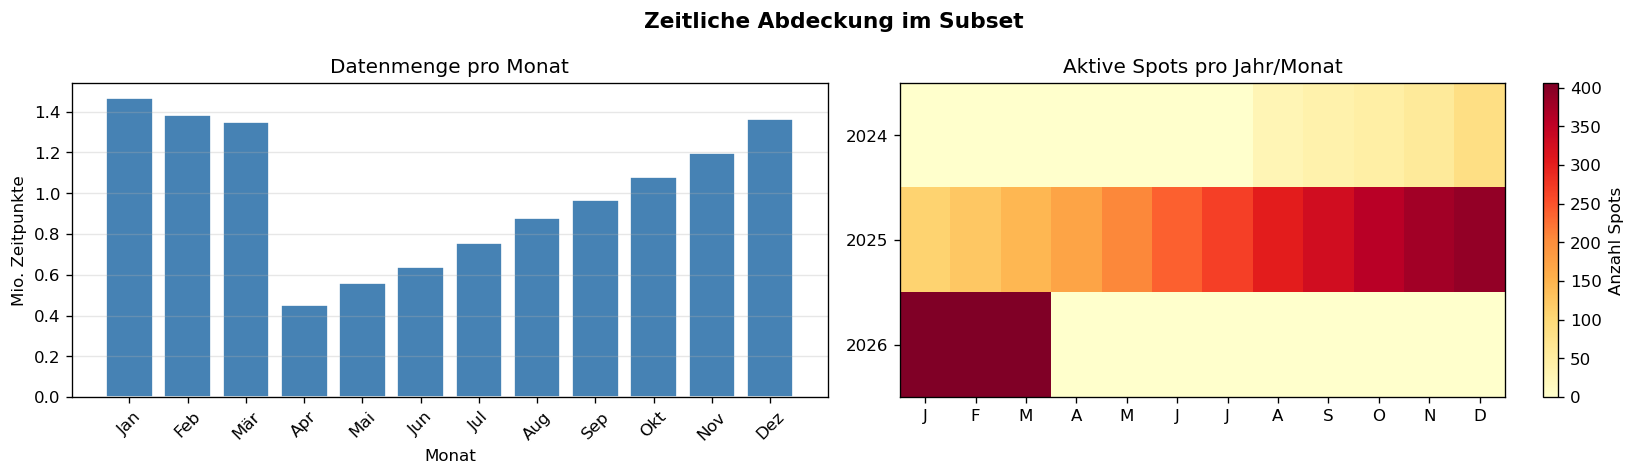

In [5]:
df['month'] = df['ts'].dt.month
df['year']  = df['ts'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Zeitliche Abdeckung im Subset', fontsize=13, fontweight='bold')

# Zeilen pro Monat
monthly = df.groupby('month').size()
axes[0].bar(monthly.index, monthly.values / 1e6, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Monat')
axes[0].set_ylabel('Mio. Zeitpunkte')
axes[0].set_title('Datenmenge pro Monat')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez'], rotation=45)
axes[0].grid(True, axis='y', alpha=0.3)

# Spots aktiv pro Monat (Heatmap Jahr × Monat)
spot_ym = df.groupby(['year', 'month'])['spot_uuid'].nunique().unstack(fill_value=0)
im = axes[1].imshow(spot_ym.values, aspect='auto', cmap='YlOrRd')
axes[1].set_yticks(range(len(spot_ym.index)))
axes[1].set_yticklabels(spot_ym.index)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Aktive Spots pro Jahr/Monat')
plt.colorbar(im, ax=axes[1], label='Anzahl Spots')

plt.tight_layout()
plt.show()

## 5. Geografische Verteilung

Scatter der Spotstandorte nach Koordinaten — zeigt ob das Subset geografisch breit verteilt ist oder regionale Cluster aufweist.

In [ ]:
# Eine Zeile pro Spot (statische Werte)
spots = df.groupby('spot_uuid', observed=True).agg(
    latitude             = ('latitude', 'first'),
    longitude            = ('longitude', 'first'),
    panel_tilt           = ('panel_tilt', 'first'),
    kwp_est              = ('kwp_est', 'first'),
    max_kwh_est          = ('max_kwh_est', 'first'),
    panel_unimodal_azimuth = ('panel_unimodal_azimuth', 'first'),
    panel_is_ew_split    = ('panel_is_ew_split', 'first'),
    n_rows               = (TARGET, 'count'),
).reset_index()

# Geografische Verteilung
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Geografische Verteilung – Subset', fontsize=13, fontweight='bold')

sc = axes[0].scatter(spots['longitude'], spots['latitude'],
                     c=spots['kwp_est'], cmap='viridis', s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='kwp_est (Anlagengröße kWp)')
axes[0].set_xlabel('Längengrad')
axes[0].set_ylabel('Breitengrad')
axes[0].set_title('Spotverteilung (Farbe = Anlagengröße)')
axes[0].grid(True, alpha=0.3)

sc2 = axes[1].scatter(spots['longitude'], spots['latitude'],
                      c=spots['n_rows'], cmap='plasma', s=20, alpha=0.7)
plt.colorbar(sc2, ax=axes[1], label='Anzahl Zeitpunkte')
axes[1].set_xlabel('Längengrad')
axes[1].set_ylabel('Breitengrad')
axes[1].set_title('Spotverteilung (Farbe = Datenlänge)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Lat-Bereich:  {spots['latitude'].min():.2f}° – {spots['latitude'].max():.2f}°")
print(f"Lon-Bereich:  {spots['longitude'].min():.2f}° – {spots['longitude'].max():.2f}°")

## 6. Anlagencharakteristik

Verteilungen von Anlagengröße (`kwp_est`), Neigungswinkel, Azimut und Beobachtungslänge. Zeigt ob das Subset eine typische Haushalts-PV-Anlage widerspiegelt.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Anlagencharakteristik – Subset', fontsize=14, fontweight='bold')

# kwp_est
ax = axes[0, 0]
ax.hist(spots['kwp_est'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.axvline(spots['kwp_est'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f"Median = {spots['kwp_est'].median():.1f} kWp")
ax.set_xlabel('Anlagengröße (kWp)'); ax.set_title('Anlagengröße kwp_est')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# panel_tilt
ax = axes[0, 1]
ax.hist(spots['panel_tilt'].dropna(), bins=30, color='steelblue', edgecolor='white')
ax.axvline(spots['panel_tilt'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f"Median = {spots['panel_tilt'].median():.1f}°")
ax.set_xlabel('Neigungswinkel (°)'); ax.set_title('Panelneigung panel_tilt')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# panel_unimodal_azimuth
ax = axes[0, 2]
az = spots['panel_unimodal_azimuth'].dropna()
ax.hist(az, bins=36, color='steelblue', edgecolor='white')
ax.axvline(180, color='red', linestyle='--', linewidth=1.5, label='Süd = 180°')
ax.set_xlabel('Azimut (°)'); ax.set_title('Panel-Ausrichtung')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# Ost-West-Split
ax = axes[1, 0]
ew_counts = spots['panel_is_ew_split'].value_counts()
bars = ax.bar(['Einfach (Süd/etc.)', 'Ost-West-Split'],
              [ew_counts.get(False, 0), ew_counts.get(True, 0)],
              color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Anlagentyp'); ax.set_ylabel('Anzahl Spots')
ax.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, [ew_counts.get(False, 0), ew_counts.get(True, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

# n_rows pro Spot (days)
ax = axes[1, 1]
days = spots['n_rows'] / 96
ax.hist(days, bins=30, color='steelblue', edgecolor='white')
ax.axvline(days.median(), color='red', linestyle='--', linewidth=1.5,
           label=f"Median = {days.median():.0f} Tage")
ax.set_xlabel('Tage im Dataset'); ax.set_title('Beobachtungslänge pro Spot')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# kwp_est vs panel_tilt scatter
ax = axes[1, 2]
sc = ax.scatter(spots['panel_tilt'].dropna(), spots.loc[spots['panel_tilt'].notna(), 'kwp_est'],
                c=spots.loc[spots['panel_tilt'].notna(), 'panel_unimodal_azimuth'],
                cmap='RdYlGn', s=18, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Azimut (°)')
ax.set_xlabel('Neigungswinkel (°)'); ax.set_ylabel('Anlagengröße (kWp)')
ax.set_title('Neigung × Größe (Farbe = Azimut)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Train/Val/Test-Split Qualität

Gleicher 80/10/10 Split wie in den Training-Scripts.

In [ ]:
# Repliziere den exakten Split
_split = np.zeros(len(df), dtype='int8')
for _, g in df.groupby('spot_uuid', observed=True):
    idx = g.index.values; ns = len(idx)
    _split[idx[int(ns*0.8):int(ns*0.9)]] = 1
    _split[idx[int(ns*0.9):]]            = 2

df['split'] = _split
split_names = {0: 'Train (80%)', 1: 'Val (10%)', 2: 'Test (10%)'}

split_stats = []
for s, name in split_names.items():
    sub = df[df['split'] == s]
    ts_min = sub['ts'].min(); ts_max = sub['ts'].max()
    split_stats.append({
        'Split': name,
        'Zeilen': f"{len(sub):,}",
        'Zeitraum von': ts_min.date(),
        'Zeitraum bis': ts_max.date(),
        'Ø kwh_norm': f"{sub[TARGET].mean():.4f}",
        'Std kwh_norm': f"{sub[TARGET].std():.4f}",
    })

display(pd.DataFrame(split_stats).set_index('Split'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Train/Val/Test Split – Subset', fontsize=13, fontweight='bold')

colors = ['steelblue', 'orange', 'green']
labels = list(split_names.values())

# KDE-ähnlich: Dichte von kwh_norm pro Split
ax = axes[0]
for s, name, c in zip([0, 1, 2], labels, colors):
    vals = df.loc[df['split'] == s, TARGET].dropna()
    ax.hist(vals, bins=80, alpha=0.55, color=c, label=name, density=True)
ax.set_xlabel('kwh_norm'); ax.set_ylabel('Dichte')
ax.set_title('kwh_norm-Verteilung pro Split')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, ax.get_xlim()[1])

# Monatliche Abdeckung pro Split
ax = axes[1]
df['month'] = df['ts'].dt.month
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
x = np.arange(12); w = 0.28
for si, (s, name, c) in enumerate(zip([0, 1, 2], labels, colors)):
    monthly = df[df['split'] == s].groupby('month').size().reindex(range(1,13), fill_value=0)
    ax.bar(x + (si-1)*w, monthly.values/1e6, w, label=name, color=c, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(month_labels)
ax.set_xlabel('Monat'); ax.set_ylabel('Mio. Zeitpunkte')
ax.set_title('Monatliche Datenverteilung pro Split')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Fazit: Ist das Subset repräsentativ?

Bewertet anhand der vorherigen Analysen ob das Subset in Bezug auf Geografie, Anlagengröße, Ausrichtung und saisonale Abdeckung repräsentativ für den Gesamtdatensatz ist.

In [9]:
print('=' * 60)
print('SUBSET-ZUSAMMENFASSUNG')
print('=' * 60)
print(f'  Spots:              {len(spots):,} von {n_total:,} total ({len(spots)/n_total*100:.1f}%)')
print(f'  Zeilen gesamt:      {len(df):,}')
print(f'  Zeitpunkte / Spot:  Ø {df.groupby("spot_uuid", observed=True).size().mean():,.0f}  (Median {df.groupby("spot_uuid", observed=True).size().median():,.0f})')
print(f'  Tage / Spot:        Ø {df.groupby("spot_uuid", observed=True).size().mean()/96:,.0f}')
print(f'  Clean Rate:         min={stats_sub["clean"].min():.3f}  Ø={stats_sub["clean"].mean():.3f}')
print(f'  Lat-Bereich:        {spots["latitude"].min():.1f}° – {spots["latitude"].max():.1f}°')
print(f'  Lon-Bereich:        {spots["longitude"].min():.1f}° – {spots["longitude"].max():.1f}°')
print(f'  Ø Anlagengröße:     {spots["kwp_est"].mean():.1f} kWp  (Median {spots["kwp_est"].median():.1f} kWp)')
print(f'  Ost-West-Split:     {spots["panel_is_ew_split"].sum()} Spots ({spots["panel_is_ew_split"].mean()*100:.1f}%)')
print()
print('Train/Val/Test Zeilenverteilung:')
for s, name in split_names.items():
    n = (df['split'] == s).sum()
    print(f'  {name:<15}: {n:>10,}  ({n/len(df)*100:.1f}%)')
print('=' * 60)

(will be re-run)


## 9. OOS-Spots: Die 100 ungesehenen Zeitreihen

Für den Out-of-Sample Test werden die **Top-100 Spots außerhalb des Trainings-Subsets** verwendet,
ausgewählt nach höchster clean rate (≥98.2%).

In [ ]:
_oos_path = Path('Model_codes/oos_spots.json')
with open(_oos_path) as f:
    oos_spots = json.load(f)

print(f"OOS Spots: {len(oos_spots)}")

# Load static info for OOS spots
_df_oos_info = ds.dataset(str(DATA_PATH)).to_table(
    columns=['spot_uuid', 'ts', TARGET, 'latitude', 'longitude', 'kwp_est',
             'panel_tilt', 'panel_is_ew_split', 'panel_unimodal_azimuth'],
    filter=pc.field('spot_uuid').isin(oos_spots)
).to_pandas()
_df_oos_info['ts'] = pd.to_datetime(_df_oos_info['ts'])
if _df_oos_info['ts'].dt.tz is not None:
    _df_oos_info['ts'] = _df_oos_info['ts'].dt.tz_convert('UTC').dt.tz_localize(None)

_oos_spots_df = _df_oos_info.groupby('spot_uuid', observed=True).agg(
    latitude=('latitude','first'),
    longitude=('longitude','first'),
    kwp_est=('kwp_est','first'),
    panel_tilt=('panel_tilt','first'),
    panel_is_ew_split=('panel_is_ew_split','first'),
    panel_unimodal_azimuth=('panel_unimodal_azimuth','first'),
    n_rows=(TARGET,'count'),
    ts_min=('ts','min'),
    ts_max=('ts','max'),
).reset_index()
_oos_spots_df['days'] = _oos_spots_df['n_rows'] / 96

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('OOS-Spots (100 ungesehene Zeitreihen) vs. Trainings-Subset', fontsize=13, fontweight='bold')

# Geo scatter OOS vs subset
ax = axes[0, 0]
ax.scatter(spots['longitude'], spots['latitude'], s=15, alpha=0.5, color='steelblue', label=f'Subset ({len(spots)})')
ax.scatter(_oos_spots_df['longitude'], _oos_spots_df['latitude'], s=25, alpha=0.8, color='tomato', label=f'OOS ({len(_oos_spots_df)})', marker='^')
ax.set_xlabel('Längengrad'); ax.set_ylabel('Breitengrad')
ax.set_title('Geografische Verteilung')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# kwp_est comparison
ax = axes[0, 1]
ax.hist(spots['kwp_est'].dropna(), bins=30, alpha=0.5, color='steelblue', label='Subset', density=True)
ax.hist(_oos_spots_df['kwp_est'].dropna(), bins=30, alpha=0.6, color='tomato', label='OOS', density=True)
ax.set_xlabel('kwp_est (kWp)'); ax.set_title('Anlagengröße')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# panel_tilt comparison
ax = axes[0, 2]
ax.hist(spots['panel_tilt'].dropna(), bins=20, alpha=0.5, color='steelblue', label='Subset', density=True)
ax.hist(_oos_spots_df['panel_tilt'].dropna(), bins=20, alpha=0.6, color='tomato', label='OOS', density=True)
ax.set_xlabel('Neigungswinkel (°)'); ax.set_title('Panel-Neigung')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# days per spot
ax = axes[1, 0]
ax.hist(spots['n_rows']/96, bins=25, alpha=0.5, color='steelblue', label='Subset', density=True)
ax.hist(_oos_spots_df['days'], bins=25, alpha=0.6, color='tomato', label='OOS', density=True)
ax.set_xlabel('Tage im Dataset'); ax.set_title('Beobachtungslänge')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Azimuth comparison
ax = axes[1, 1]
_sub_az = spots['panel_unimodal_azimuth'].dropna()
_oos_az = _oos_spots_df['panel_unimodal_azimuth'].dropna()
ax.hist(_sub_az, bins=36, alpha=0.5, color='steelblue', label='Subset', density=True)
ax.hist(_oos_az, bins=36, alpha=0.6, color='tomato', label='OOS', density=True)
ax.axvline(180, color='black', linestyle='--', linewidth=0.8, label='Süd=180°')
ax.set_xlabel('Azimut (°)'); ax.set_title('Panel-Ausrichtung')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# EW-Split comparison
ax = axes[1, 2]
_cats = ['Einfach', 'Ost-West']
_sub_ew = [spots['panel_is_ew_split'].eq(False).sum(), spots['panel_is_ew_split'].eq(True).sum()]
_oos_ew = [_oos_spots_df['panel_is_ew_split'].eq(False).sum(), _oos_spots_df['panel_is_ew_split'].eq(True).sum()]
x = np.arange(len(_cats)); w = 0.35
ax.bar(x - w/2, _sub_ew, w, label='Subset', color='steelblue', edgecolor='white')
ax.bar(x + w/2, _oos_ew, w, label='OOS',    color='tomato',    edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(_cats)
ax.set_title('Anlagentyp'); ax.set_ylabel('Anzahl Spots')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print('\n=== OOS vs. Subset Vergleich ===')
for label, df_ in [('Subset (406)', spots), ('OOS (100)', _oos_spots_df)]:
    n_rows_col = 'n_rows' if 'n_rows' in df_.columns else 'n_rows'
    days_col   = df_['n_rows']/96 if 'n_rows' in df_.columns else df_['days']
    print(f"\n{label}:")
    print(f"  Lat:         {df_['latitude'].min():.1f}° – {df_['latitude'].max():.1f}°")
    print(f"  kwp_est:     median={df_['kwp_est'].median():.1f} kWp")
    print(f"  Neigung:     median={df_['panel_tilt'].median():.1f}°")
    print(f"  Tage/Spot:   median={days_col.median():.0f}")
    print(f"  EW-Split:    {df_['panel_is_ew_split'].mean()*100:.1f}%")